In [33]:
import pandas as pd # Import pandas for data manipulation
import numpy as np # Import numpy for numerical operations
import matplotlib.pyplot as plt # Import matplotlib for plotting
import seaborn as sns # Import seaborn for enhanced visualizations

df = pd.read_csv("Subscription Cohort Analysis Data.csv") # Load the main subscription data into a DataFrame

In [34]:
df.describe() # Display descriptive statistics of the DataFrame
df.columns # Display the column names of the DataFrame

Index(['customer_id', 'created_date', 'canceled_date', 'subscription_cost',
       'subscription_interval', 'was_subscription_paid'],
      dtype='object')

In [35]:
df.duplicated().sum() # Calculate and display the number of duplicate rows
df.isna().sum() # Calculate and display the number of missing values per column
df.head(5) # Display the first 5 rows of the DataFrame for a quick preview

,customer_id,created_date,canceled_date,subscription_cost,subscription_interval,was_subscription_paid
0,154536156,2022-09-01,NaN,39,month,Yes
1,149713408,2022-09-01,2022-09-02,39,month,No
2,153756284,2022-09-01,2022-09-02,39,month,No
3,121253113,2022-09-01,2022-09-23,39,month,Yes
4,154467210,2022-09-01,2023-06-29,39,month,Yes


In [36]:
df['created_date'] = pd.to_datetime(df['created_date']) # Convert 'created_date' column to datetime objects
df['canceled_date'] = pd.to_datetime(df['canceled_date']) # Convert 'canceled_date' column to datetime objects

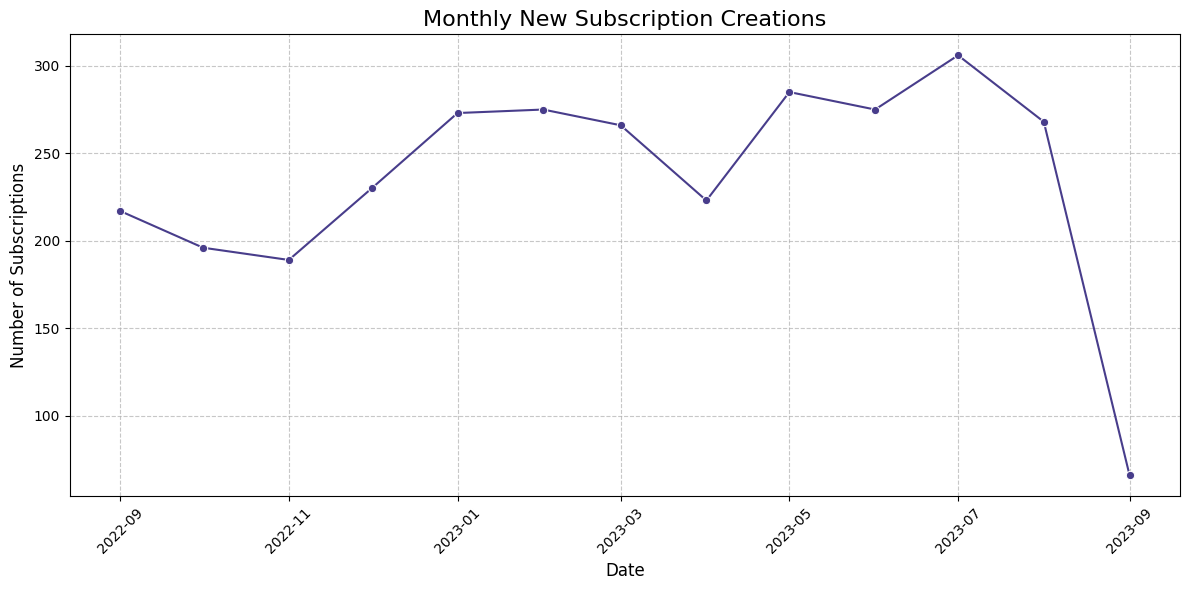

In [37]:
monthly_creations = df.groupby(df['created_date'].dt.to_period('M')).size().reset_index(name='count') # Group by month of creation and count new subscriptions
monthly_creations['created_date'] = monthly_creations['created_date'].dt.to_timestamp() # Convert Period back to Timestamp for plotting

plt.figure(figsize=(12, 6)) # Create a new figure with a specified size
sns.lineplot(x='created_date', y='count', data=monthly_creations, marker='o', color='darkslateblue') # Create a line plot of monthly new subscription creations
plt.title('Monthly New Subscription Creations', fontsize=16) # Set the plot title
plt.xlabel('Date', fontsize=12) # Set the x-axis label
plt.ylabel('Number of Subscriptions', fontsize=12) # Set the y-axis label
plt.grid(True, linestyle='--', alpha=0.7) # Add a grid to the plot
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show() # Display the plot

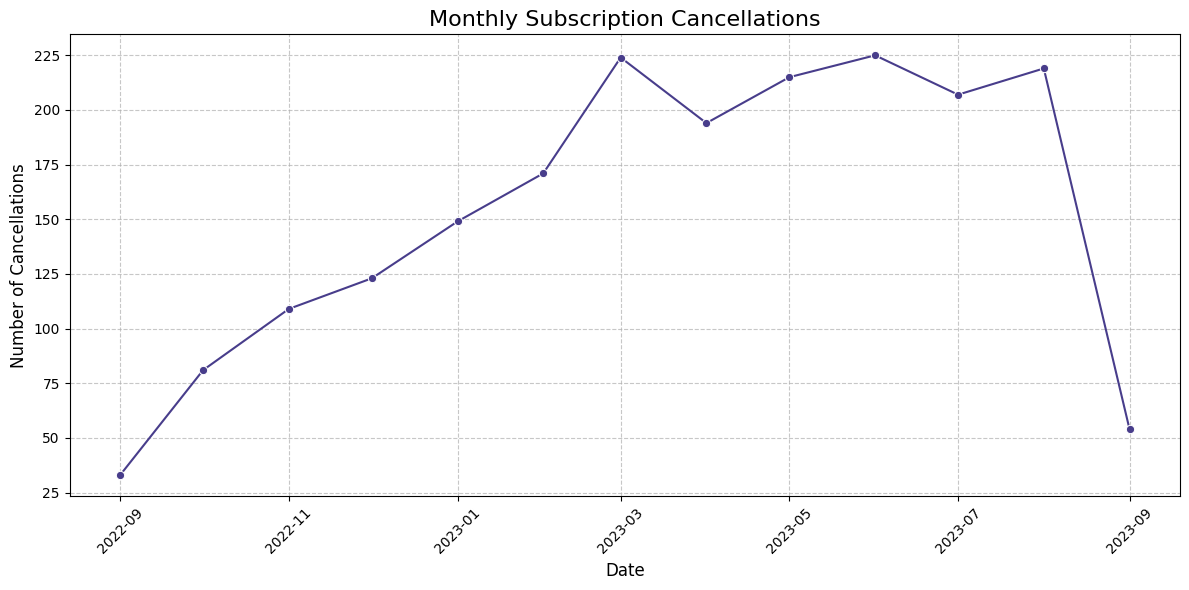

In [38]:
monthly_cancellations = df.dropna(subset=['canceled_date']).groupby(df['canceled_date'].dt.to_period('M')).size().reset_index(name='count') # Group by month of cancellation (excluding NaNs) and count cancellations
monthly_cancellations['canceled_date'] = monthly_cancellations['canceled_date'].dt.to_timestamp() # Convert Period back to Timestamp for plotting

plt.figure(figsize=(12, 6)) # Create a new figure with a specified size
sns.lineplot(x='canceled_date', y='count', data=monthly_cancellations, marker='o', color='darkslateblue') # Create a line plot of monthly subscription cancellations
plt.title('Monthly Subscription Cancellations', fontsize=16) # Set the plot title
plt.xlabel('Date', fontsize=12) # Set the x-axis label
plt.ylabel('Number of Cancellations', fontsize=12) # Set the y-axis label
plt.grid(True, linestyle='--', alpha=0.7) # Add a grid to the plot
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show() # Display the plot

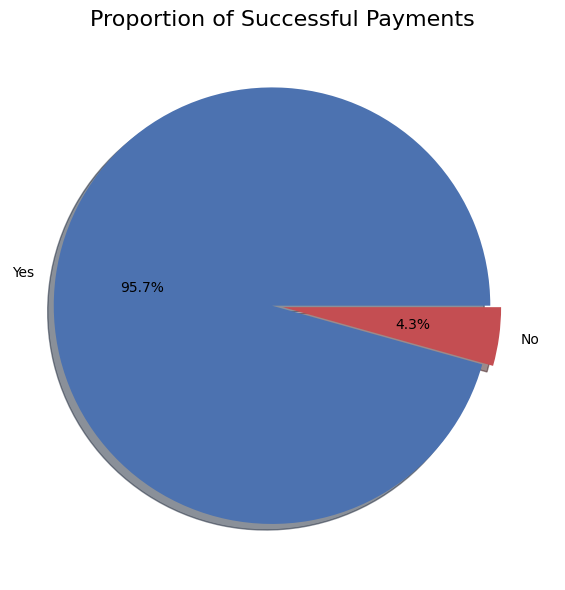

In [39]:
plt.figure(figsize=(8, 6)) # Create a new figure with a specified size
df['was_subscription_paid'].value_counts().plot.pie(autopct='%1.1f%%', colors=[sns.color_palette("deep")[0], sns.color_palette("deep")[3]], explode=[0.05, 0], shadow=True) # Create a pie chart showing the proportion of successful payments
plt.title('Proportion of Successful Payments', fontsize=16) # Set the plot title
plt.ylabel('') # Hide the default y-label for the pie chart
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show() # Display the plot

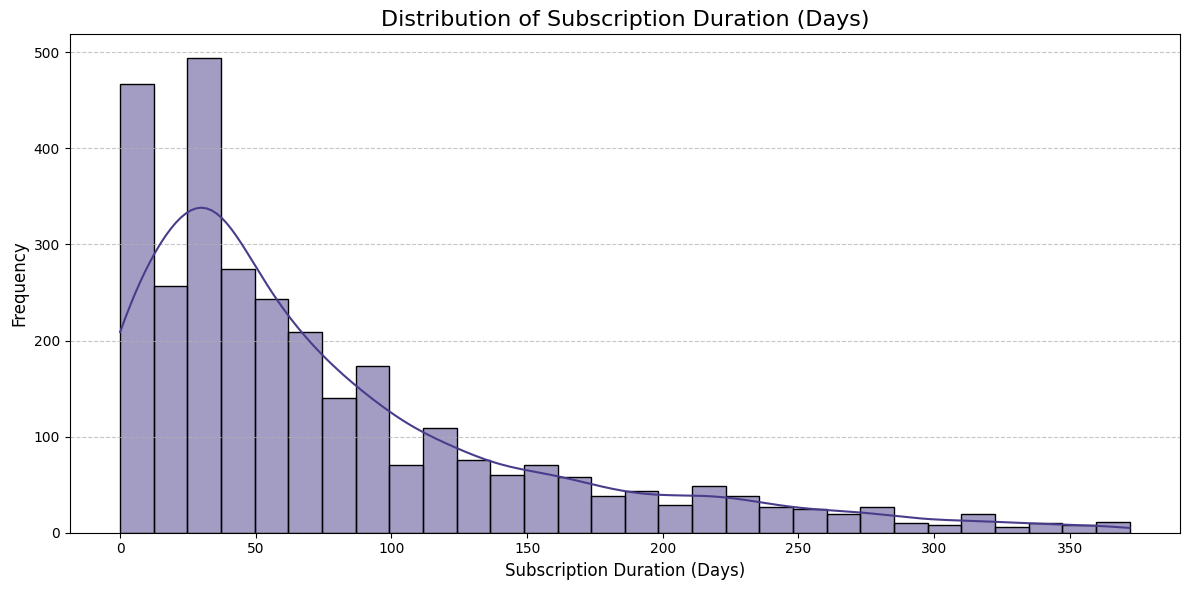

In [40]:
latest_date = df['created_date'].max() # Find the latest creation date in the dataset
df['actual_canceled_date'] = df['canceled_date'].fillna(latest_date) # Fill NaN values in 'canceled_date' with the latest creation date (for active subscriptions)
df['subscription_duration_days'] = (df['actual_canceled_date'] - df['created_date']).dt.days # Calculate subscription duration in days

plt.figure(figsize=(12, 6)) # Create a new figure with a specified size
sns.histplot(df['subscription_duration_days'], bins=30, kde=True, color='darkslateblue') # Create a histogram with KDE for subscription duration
plt.title('Distribution of Subscription Duration (Days)', fontsize=16) # Set the plot title
plt.xlabel('Subscription Duration (Days)', fontsize=12) # Set the x-axis label
plt.ylabel('Frequency', fontsize=12) # Set the y-axis label
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid to the plot
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show() # Display the plot

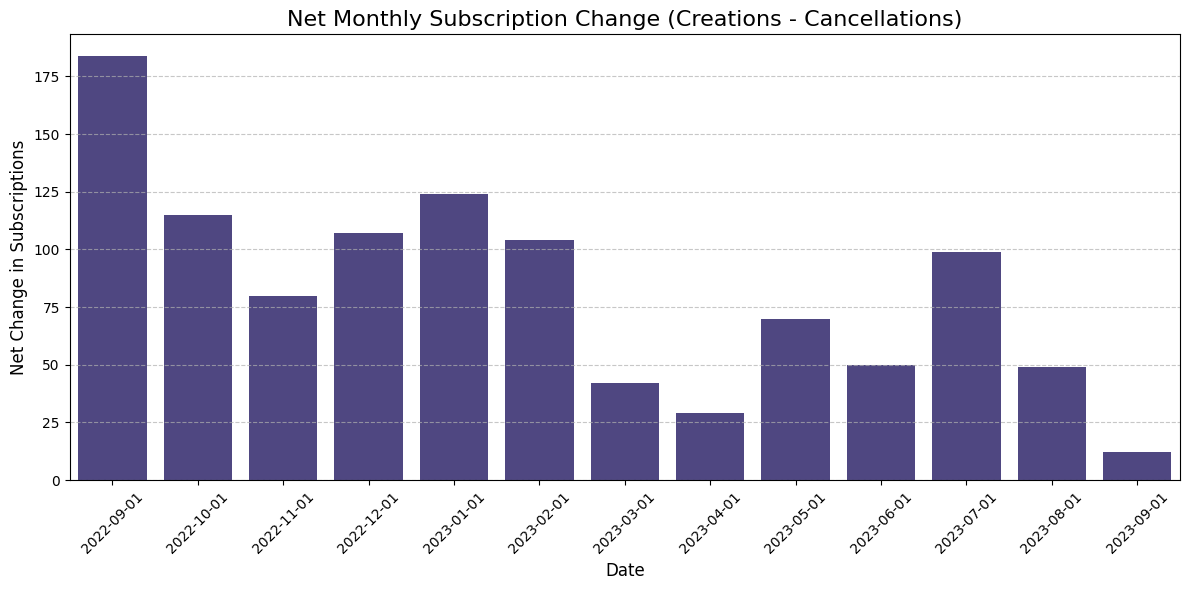

In [41]:
monthly_summary = pd.merge(monthly_creations, monthly_cancellations, left_on='created_date', right_on='canceled_date', suffixes=('_creations', '_cancellations'), how='outer').fillna(0) # Merge monthly creations and cancellations
monthly_summary['net_change'] = monthly_summary['count_creations'] - monthly_summary['count_cancellations'] # Calculate the net change in subscriptions

plt.figure(figsize=(12, 6)) # Create a new figure with a specified size
sns.barplot(x='created_date', y='net_change', data=monthly_summary, color='darkslateblue') # Create a bar plot of net monthly subscription change
plt.title('Net Monthly Subscription Change (Creations - Cancellations)', fontsize=16) # Set the plot title
plt.xlabel('Date', fontsize=12) # Set the x-axis label
plt.ylabel('Net Change in Subscriptions', fontsize=12) # Set the y-axis label
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid to the plot
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show() # Display the plot

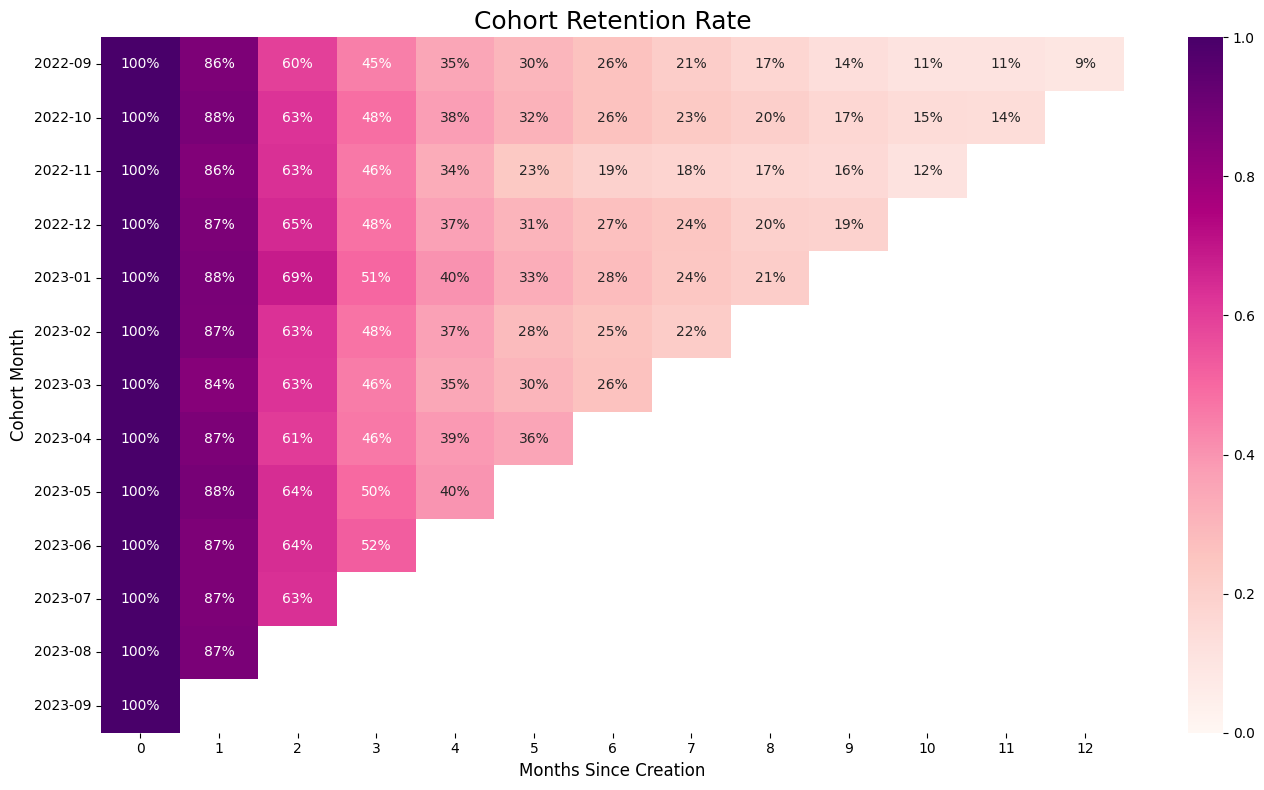

In [42]:
# 1. Ensure date columns are Period objects for month-based calculations
df['created_month_period'] = df['created_date'].dt.to_period('M') # Convert 'created_date' to monthly Period objects
# Use the already calculated 'actual_canceled_date' which handles NaT values
df['actual_canceled_month_period'] = df['actual_canceled_date'].dt.to_period('M') # Convert 'actual_canceled_date' to monthly Period objects

# 2. Define cohort group (month of creation)
df['cohort_group'] = df['created_month_period'] # Set the cohort group as the creation month

# 3. Calculate max cohort period (duration in months) for each customer
df['max_cohort_period'] = (df['actual_canceled_month_period'] - df['created_month_period']).apply(lambda x: x.n) # Calculate the duration in months from creation to actual cancellation

# 4. Create an exploded DataFrame with one row per customer-active-month
# This generates a list of cohort periods for each customer (e.g., [0, 1, 2] for a 3-month subscription)
df_exploded = df.assign(cohort_period=df['max_cohort_period'].apply(lambda x: list(range(x + 1)))).explode('cohort_period') # Explode the DataFrame to have one row per active month for each customer

# 5. Calculate activity_month from cohort_group and cohort_period using vectorized operations
# Explicitly cast cohort_period to int to ensure vectorized addition with Period objects
df_exploded['cohort_period'] = df_exploded['cohort_period'].astype(int) # Ensure 'cohort_period' is an integer type
df_exploded['activity_month'] = df_exploded['cohort_group'] + df_exploded['cohort_period'] # Calculate the activity month by adding cohort period to cohort group

# 6. Count unique customers per cohort_group and cohort_period (number of active customers)
cohort_counts = df_exploded.groupby(['cohort_group', 'cohort_period'])['customer_id'].nunique().reset_index(name='active_customers') # Count unique active customers for each cohort and period

# 7. Get the initial size of each cohort (customers at cohort_period 0)
cohort_sizes = cohort_counts[cohort_counts['cohort_period'] == 0][['cohort_group', 'active_customers']].rename(columns={'active_customers': 'cohort_size'}) # Get the initial size of each cohort (customers at month 0)

# 8. Merge to calculate retention rate
cohort_retention = pd.merge(cohort_counts, cohort_sizes, on='cohort_group') # Merge cohort counts with cohort sizes
cohort_retention['retention_rate'] = cohort_retention['active_customers'] / cohort_retention['cohort_size'] # Calculate the retention rate

# 9. Pivot for heatmap
retention_pivot = cohort_retention.pivot_table(index='cohort_group', columns='cohort_period', values='retention_rate') # Pivot the data to create a matrix suitable for a heatmap

# Plotting the heatmap
plt.figure(figsize=(14, 8)) # Create a new figure with a specified size
sns.heatmap(retention_pivot, annot=True, fmt='.0%', cmap='RdPu', vmin=0, vmax=1) # Using 'RdPu' for professional palette # Create a heatmap of the retention pivot table
plt.title('Cohort Retention Rate', fontsize=18) # Set the plot title
plt.xlabel('Months Since Creation', fontsize=12) # Set the x-axis label
plt.ylabel('Cohort Month', fontsize=12) # Set the y-axis label
plt.yticks(rotation=0) # Ensure y-axis labels are not rotated
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show() # Display the plot

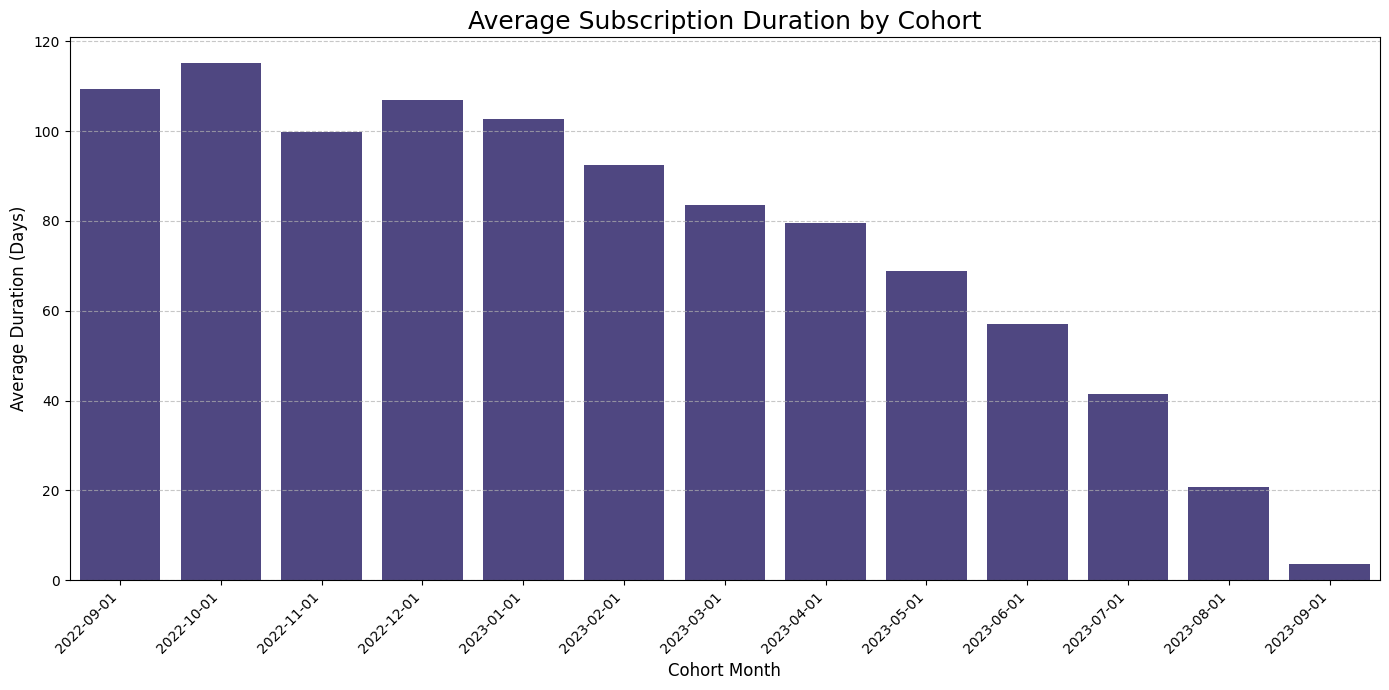

In [43]:
# Calculate the average subscription duration for each cohort
average_duration_by_cohort = df.groupby('cohort_group')['subscription_duration_days'].mean().reset_index()

# Convert 'cohort_group' from Period to Timestamp for better plotting
average_duration_by_cohort['cohort_group_ts'] = average_duration_by_cohort['cohort_group'].dt.to_timestamp()

# Plotting the average subscription duration by cohort
plt.figure(figsize=(14, 7)) # Create a new figure with a specified size
sns.barplot(x='cohort_group_ts', y='subscription_duration_days', data=average_duration_by_cohort, color='darkslateblue') # Create a bar plot
plt.title('Average Subscription Duration by Cohort', fontsize=18) # Set the plot title
plt.xlabel('Cohort Month', fontsize=12) # Set the x-axis label
plt.ylabel('Average Duration (Days)', fontsize=12) # Set the y-axis label
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid to the plot
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show() # Display the plot